# Task 2 — Image Data Collection & Processing
### Formative 2: Multimodal Data Preprocessing

> **Photo naming:** one folder per member under `images/`, with files named `neutral` / `smiling` / `surprised` and any of these extensions: `.jpg`, `.jpeg`, or `.png`.
> ```
> images/
>   <member_name>/
>     neutral.jpg   (or .jpeg / .png)
>     smiling.jpg
>     surprised.jpg
> ```
> The loader auto-discovers whatever member folders and supported extensions are present — no code changes needed when swapping photos.

This notebook covers:
1. Loading and displaying each member's images
2. Augmentations (rotation, flip, grayscale)
3. Feature extraction (color histograms, HOG, grayscale/pixel statistics) into `image_features.csv`


In [22]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage import exposure

IMAGES_DIR = 'images'
EXPRESSIONS = ['neutral', 'smiling', 'surprised']

def discover_members(images_dir=IMAGES_DIR):
    '''Finds every member subfolder and which expression photos exist for them.'''
    members = {}
    for member in sorted(os.listdir(images_dir)):
        member_path = os.path.join(images_dir, member)
        if not os.path.isdir(member_path):
            continue
        found = {}
        for exp in EXPRESSIONS:
            for ext in ('jpg', 'jpeg', 'png'):
                candidate = os.path.join(member_path, f'{exp}.{ext}')
                if os.path.exists(candidate):
                    found[exp] = candidate
                    break
        if found:
            members[member] = found
    return members

members = discover_members()
for m, files in members.items():
    print(m, '->', list(files.keys()))


amaliza -> ['neutral', 'smiling', 'surprised']
emmanuel -> ['neutral', 'smiling', 'surprised']
musana -> ['neutral', 'smiling', 'surprised']
vestine -> ['neutral', 'smiling', 'surprised']


## 1. Load & Display Sample Images

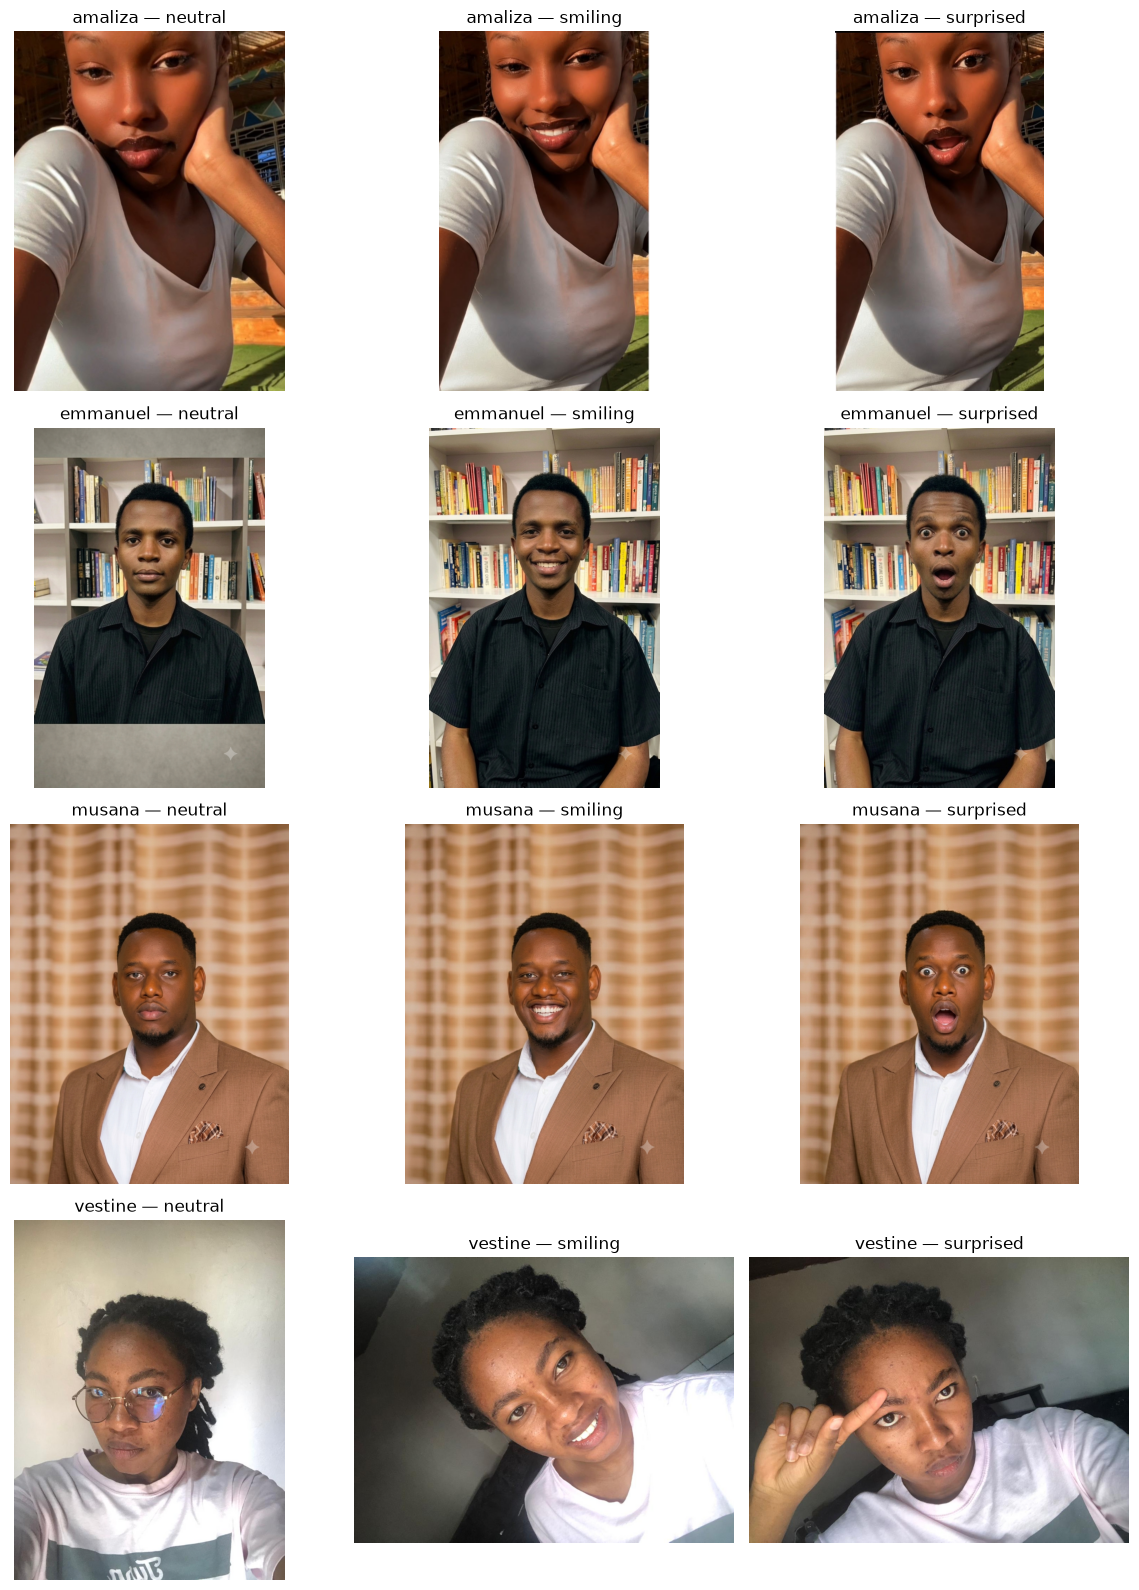

In [23]:
def load_image(path):
    return Image.open(path).convert('RGB')

n_members = len(members)
fig, axes = plt.subplots(n_members, len(EXPRESSIONS), figsize=(4*len(EXPRESSIONS), 4*n_members), squeeze=False)

for row, (member, files) in enumerate(members.items()):
    for col, exp in enumerate(EXPRESSIONS):
        ax = axes[row][col]
        if exp in files:
            img = load_image(files[exp])
            ax.imshow(img)
            ax.set_title(f'{member} — {exp}')
        else:
            ax.set_title(f'{member} — {exp} (missing)')
        ax.axis('off')

plt.tight_layout()
plt.savefig('image_samples_grid.png')
plt.show()


## 2. Augmentations

At least two augmentations per image, as required: **rotation**, **horizontal flip**, and **grayscale conversion**. Each is applied independently to every original photo, and every augmented version also gets its own row of extracted features later on — so the feature set captures pose/lighting variation, not just the raw photo.


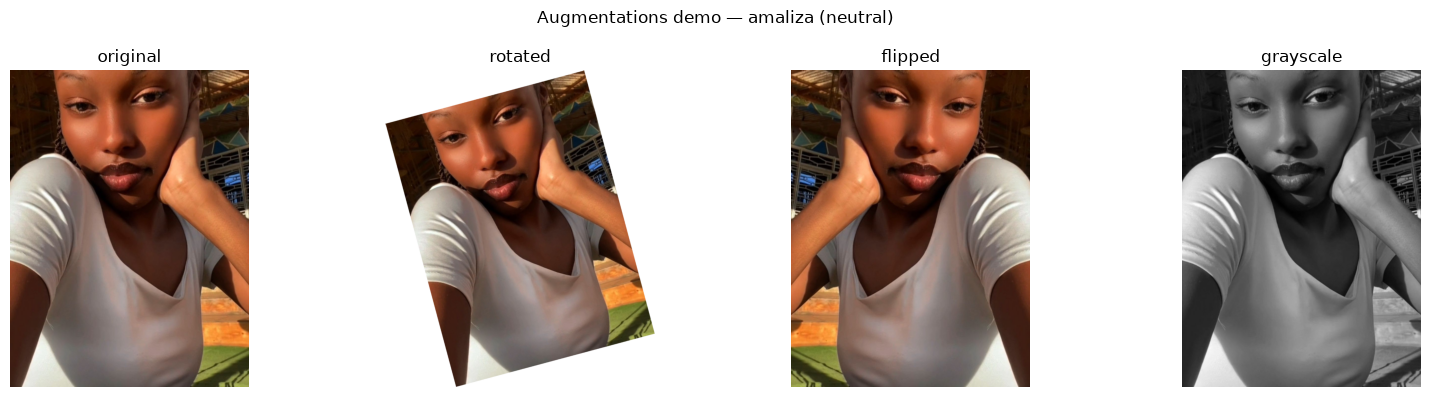

In [24]:
def augment_rotate(img, degrees=15):
    return img.rotate(degrees, expand=True, fillcolor=(255,255,255))

def augment_flip(img):
    return img.transpose(Image.FLIP_LEFT_RIGHT)

def augment_grayscale(img):
    return img.convert('L').convert('RGB')  # keep 3 channels for a consistent pipeline

AUGMENTATIONS = {
    'original': lambda img: img,
    'rotated': augment_rotate,
    'flipped': augment_flip,
    'grayscale': augment_grayscale,
}

# Show every augmentation for one member/expression as a sanity check
demo_member = next(iter(members))
demo_exp = next(iter(members[demo_member]))
demo_img = load_image(members[demo_member][demo_exp])

fig, axes = plt.subplots(1, len(AUGMENTATIONS), figsize=(4*len(AUGMENTATIONS), 4))
for ax, (name, fn) in zip(axes, AUGMENTATIONS.items()):
    ax.imshow(fn(demo_img))
    ax.set_title(name)
    ax.axis('off')
plt.suptitle(f'Augmentations demo — {demo_member} ({demo_exp})')
plt.tight_layout()
plt.savefig('augmentations_demo.png')
plt.show()


## 3. Feature Extraction

For every (member, expression, augmentation) combination, three complementary feature families are extracted and flattened into one row:

- **Color histogram** — 16 bins per RGB channel (48 values) — captures overall color/lighting distribution.
- **HOG (Histogram of Oriented Gradients)** — captures edge/shape structure, summarized to a fixed-length vector via its own histogram-of-gradients binning.
- **Grayscale pixel statistics** — mean, std, min, max brightness — a compact global-intensity summary.

These are saved into `image_features.csv`, one row per image variant.


In [25]:
def color_histogram(img, bins=16):
    arr = np.array(img)
    feats = []
    for ch in range(3):
        hist, _ = np.histogram(arr[:, :, ch], bins=bins, range=(0, 255), density=True)
        feats.extend(hist.tolist())
    return feats  # length = 3 * bins

def hog_features(img, pixels_per_cell=(16, 16)):
    gray = rgb2gray(np.array(img))
    fd = hog(gray, orientations=9, pixels_per_cell=pixels_per_cell,
             cells_per_block=(2, 2), feature_vector=True)
    # HOG length varies with image size; summarize to a fixed-length histogram of its own values
    hog_hist, _ = np.histogram(fd, bins=32, density=True)
    return hog_hist.tolist()

def grayscale_stats(img):
    gray = np.array(img.convert('L'), dtype=np.float64)
    return {
        'gray_mean': gray.mean(),
        'gray_std': gray.std(),
        'gray_min': gray.min(),
        'gray_max': gray.max(),
    }

def extract_features(img):
    row = {}
    row.update(grayscale_stats(img))
    for i, v in enumerate(color_histogram(img)):
        row[f'color_hist_{i}'] = v
    for i, v in enumerate(hog_features(img)):
        row[f'hog_hist_{i}'] = v
    return row


In [26]:
records = []
for member, files in members.items():
    for exp, path in files.items():
        base_img = load_image(path)
        for aug_name, aug_fn in AUGMENTATIONS.items():
            aug_img = aug_fn(base_img)
            feats = extract_features(aug_img)
            feats.update({
                'member': member,
                'expression': exp,
                'augmentation': aug_name,
                'source_file': path,
                'width': aug_img.size[0],
                'height': aug_img.size[1],
            })
            records.append(feats)

image_features = pd.DataFrame(records)
id_cols = ['member', 'expression', 'augmentation', 'source_file', 'width', 'height']
feature_cols = [c for c in image_features.columns if c not in id_cols]
image_features = image_features[id_cols + feature_cols]

print('image_features shape:', image_features.shape)
image_features.head()


image_features shape: (48, 90)


,member,expression,augmentation,source_file,width,height,gray_mean,gray_std,gray_min,gray_max,...,hog_hist_22,hog_hist_23,hog_hist_24,hog_hist_25,hog_hist_26,hog_hist_27,hog_hist_28,hog_hist_29,hog_hist_30,hog_hist_31
0,amaliza,neutral,original,images/amaliza/neutral.jpg,966,1280,95.258932,54.745958,0.0,255.0,...,0.013461,0.007062,0.002869,0.000883,0.000883,0.000883,0.000441,0.000662,0.000662,0.000441
1,amaliza,neutral,rotated,images/amaliza/neutral.jpg,1266,1488,150.150594,87.878134,0.0,255.0,...,0.009910,0.000000,0.000000,0.000000,0.000000,0.000124,0.000000,0.000000,0.000000,0.001363
2,amaliza,neutral,flipped,images/amaliza/neutral.jpg,966,1280,95.258932,54.745958,0.0,255.0,...,0.004771,0.003687,0.003470,0.000217,0.000867,0.000000,0.000651,0.000217,0.000651,0.000651
3,amaliza,neutral,grayscale,images/amaliza/neutral.jpg,966,1280,95.258932,54.745958,0.0,255.0,...,0.012624,0.004135,0.001741,0.001306,0.000653,0.000435,0.001088,0.000435,0.000218,0.000435
4,amaliza,smiling,original,images/amaliza/smiling.jpg,585,1002,98.068402,59.021013,0.0,254.0,...,0.012379,0.009998,0.001428,0.000952,0.000000,0.000476,0.000476,0.000476,0.000476,0.000952


## 4. Validation

In [27]:
expected_rows = sum(len(files) for files in members.values()) * len(AUGMENTATIONS)
print('Expected rows (images x augmentations):', expected_rows)
print('Actual rows:', len(image_features))
assert len(image_features) == expected_rows, 'Row count mismatch — check for load failures.'
print('PASS')

print('\nNulls in feature matrix:', image_features[feature_cols].isnull().sum().sum())
print('Rows per member:\n', image_features.groupby('member').size())


Expected rows (images x augmentations): 48
Actual rows: 48
PASS

Nulls in feature matrix: 0
Rows per member:
 member
amaliza     12
emmanuel    12
musana      12
vestine     12
dtype: int64


## 5. Save Features

In [28]:
image_features.to_csv('image_features.csv', index=False)
print('Saved image_features.csv —', image_features.shape)


Saved image_features.csv — (48, 90)
